# 02 · MLP baseline
**Owner:** shared by all members (see contribution log)

A classical, non-convolutional baseline: each MRI slice is resized to 64 × 64 grayscale,
scaled to [0, 1] and flattened to 4,096 values, then passed through fully connected layers.
It has no notion of spatial neighbourhoods, so it shows how much the CNNs gain from
convolutional feature learning.

In [1]:
import os, sys
os.environ.setdefault("KERAS_BACKEND", "torch")   # Keras 3 backend used for our runs (CPU); "tensorflow" also works
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))        # make the project's src/ package importable

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from src import config, data_pipeline as dp, models, features, training

keras.utils.set_random_seed(config.SEED)
print("Keras", keras.__version__, "| backend:", keras.backend.backend())

Keras 3.15.1 | backend: torch


In [2]:
X_train, y_train = dp.generator_to_arrays(dp.make_mlp_generator("train"))
X_val, y_val = dp.generator_to_arrays(dp.make_mlp_generator("val"))
manifest = pd.read_csv(config.SPLIT_MANIFEST)
class_weight = dp.class_weights(manifest)
print("train", X_train.shape, "val", X_val.shape, "| class weights", class_weight)

Found 4343 images belonging to 2 classes.


Found 1086 images belonging to 2 classes.


train (4343, 64, 64, 1) val (1086, 64, 64, 1) | class weights {0: 2.1185365853658538, 1: 0.654460518384569}


In [3]:
mlp = models.build_mlp()
mlp.summary()

Model: "mlp_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_64x64_gray (InputLayer)     │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,163,586 (8.25 MB)

 Trainable params: 2,163,586 (8.25 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = training.train(mlp, X_train, y_train, X_val, y_val,
                         learning_rate=config.MLP_LR, class_weight=class_weight)

Epoch 1/30


136/136 - 2s - 16ms/step - accuracy: 0.6040 - loss: 0.5803 - val_accuracy: 0.8886 - val_loss: 0.4025


Epoch 2/30


136/136 - 2s - 15ms/step - accuracy: 0.7787 - loss: 0.4438 - val_accuracy: 0.9300 - val_loss: 0.2941


Epoch 3/30


...

136/136 - 3s - 21ms/step - accuracy: 0.9786 - loss: 0.0633 - val_accuracy: 0.9715 - val_loss: 0.1211


Epoch 29/30


136/136 - 3s - 22ms/step - accuracy: 0.9811 - loss: 0.0628 - val_accuracy: 0.9715 - val_loss: 0.1043


Epoch 30/30


136/136 - 3s - 21ms/step - accuracy: 0.9770 - loss: 0.0649 - val_accuracy: 0.9724 - val_loss: 0.1155


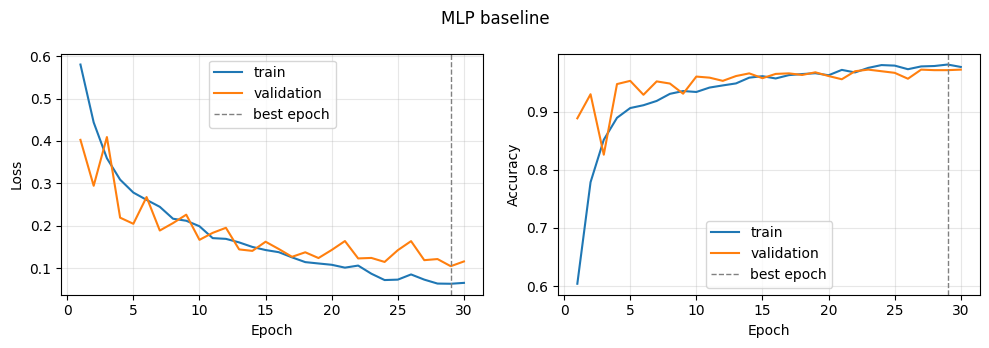

    accuracy: 0.9715
   precision: 0.9784
      recall: 0.9843
 specificity: 0.9297
          f1: 0.9814
    macro_f1: 0.9601
     roc_auc: 0.9870
   confusion: [[TN, FP], [FN, TP]] = [[238, 18], [13, 817]]


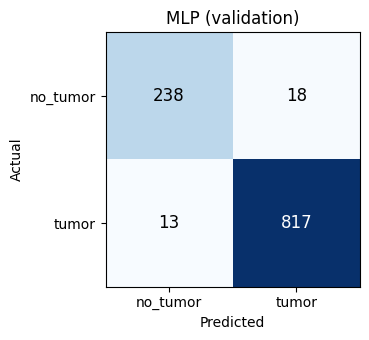

epochs run: 30 | best epoch: 29 | training time: 82.7 s


In [5]:
training.plot_history(history, "MLP baseline", config.FIG_DIR / "mlp_curves.png")
metrics, prob, pred = training.evaluate(mlp, X_val, y_val)
training.print_metrics(metrics)
training.plot_confusion(metrics["confusion_matrix"], "MLP (validation)", config.FIG_DIR / "mlp_confusion.png")
record = training.save_results("mlp_baseline", metrics, history, mlp,
                               extra={"input": "64x64 grayscale, flattened", "learning_rate": config.MLP_LR})
print("epochs run:", record["epochs_run"], "| best epoch:", record["best_epoch"],
      "| training time:", record["train_seconds"], "s")